# ps-gnn: Complete Training & Analysis Pipeline

This notebook runs the **entire ps-gnn pipeline end-to-end** on synthetic InSAR
data, exercising every stage of the package and every analysis tool it ships
with:

1. Synthetic data generation (background noise + realistic PS points + planted
   "false neighbor" hard negatives + borderline-ADI PS clusters)
2. Feature engineering & graph construction
3. Model architecture (PS-GNN: GCN → GAT → SAGE)
4. Training (spatial-block CV, curriculum learning, physics-informed loss)
5. **Attention-mechanism diagnostic** — does the GAT layer learn to distrust
   deceptive neighbors?
6. Tiled inference with Monte Carlo Dropout uncertainty
7. Classification performance analysis (confusion matrix, PR curve, calibration)
8. Spatial statistics (Moran's I, Ripley's K)
9. Explainability (SHAP feature attribution)
10. **Borderline-ADI recall experiment** — does graph reasoning beat classical
    ADI thresholding where it should?
11. SBAS time-series validation vs. a genuine classical baseline
12. Interactive 2D map visualization
13. Interactive 3D terrain visualization
14. Automated HTML report generation

The synthetic-data injection and diagnostic functions used here come from
`synthetic_pipeline_utils.py`, a small companion module shared with
`run_synthetic_pipeline_hardened.py` — see that script for the full-scale
(50-epoch) version of this same experiment. This notebook uses a smaller,
faster configuration so it can be run interactively in a few minutes while
still exercising every stage.

**Everything below is deterministic** (`torch.manual_seed` + `np.random.default_rng`
are both seeded) — re-running this notebook reproduces the exact same numbers.


## 0. Setup

In [1]:

import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from ps_gnn.data.preprocessing import (
    FEATURE_NAMES, GraphConstructionConfig, build_graph, compute_node_features,
)
from ps_gnn.models.ps_gnn import PSGNN
from ps_gnn.models.losses import PhysicsInformedPSLoss
from ps_gnn.training.trainer import Trainer, TrainerConfig
from ps_gnn.inference.detector import PSDetector, TilingConfig
from ps_gnn.validation.sbas_check import run_sbas_validation
from ps_gnn.analytics.explainability import explain_node, aggregate_global_feature_importance
from ps_gnn.analytics.spatial_stats import morans_i_residuals, ripleys_k_clustering, calibration_curve
from ps_gnn.analytics.report_generator import generate_html_report
from ps_gnn.visualization.charts import plot_training_curves, plot_confusion_matrix, plot_pr_curve
from ps_gnn.visualization.maps import create_folium_map, create_3d_terrain_plot

from synthetic_pipeline_utils import (
    ROLE_BACKGROUND, ROLE_TRUE_PS, ROLE_FALSE_NEIGHBOR, ROLE_BORDERLINE_PS,
    inject_realistic_ps_with_false_neighbors, inject_borderline_ps_clusters,
    compute_edge_role_statistics, compute_attention_by_edge_role,
    build_adi_baseline_mask, compute_recall_by_role,
    diagnose_confidence_by_hit_miss, diagnose_spatial_contamination,
)

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Precision loss")
logging.basicConfig(level=logging.WARNING)  # keep package logs quiet; this notebook narrates instead
plt.rcParams["figure.facecolor"] = "white"

SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete. CUDA available:", torch.cuda.is_available())


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. CUDA available: False


## 1. Synthetic Data Generation

We build a synthetic Sentinel-1-like amplitude/phase stack with three
deliberately distinct point types, designed to stress-test specific claims
about PS-GNN (see the module docstrings in `synthetic_pipeline_utils.py` for
the full reasoning behind each):

- **Background**: Gamma-distributed amplitude noise, uniform random phase —
  no real scatterers, just clutter.
- **Easy PS points**: near-zero ADI, near-zero phase variance — the
  "textbook" persistent scatterer. Each one also gets several **false
  neighbor** pixels planted 1-2px away: amplitude-unstable (vegetation-like)
  pixels whose phase is deliberately correlated with their parent PS, so a
  naive proximity-based method would treat them as corroborating evidence.
- **Borderline-ADI PS clusters**: genuine scatterers whose *individual* ADI
  (~0.30) exceeds the classical StaMPS threshold (0.25) — a fixed cutoff
  would reject them — but whose members are placed in small clusters sharing
  a common phase signal, so they can *only* be recovered through mutual
  corroboration.


In [2]:

T_STEPS, HEIGHT, WIDTH = 20, 96, 96
N_PS = 100
N_FALSE_NEIGHBORS_PER_PS = 3
N_BORDERLINE_CLUSTERS = 8
BORDERLINE_CLUSTER_SIZE = 4

base_amp = rng.gamma(shape=2.0, scale=10.0, size=(T_STEPS, HEIGHT, WIDTH)).astype(np.float32)
base_phase = rng.uniform(-np.pi, np.pi, size=(T_STEPS, HEIGHT, WIDTH)).astype(np.float32)
worldcover = np.full((HEIGHT, WIDTH), 30, dtype=np.int32)  # grassland background

# Synthetic DEM (Gaussian hill + noise) for the 3D terrain visualization later.
y_coords, x_coords = np.meshgrid(np.arange(HEIGHT), np.arange(WIDTH), indexing="ij")
cx, cy = WIDTH // 2, HEIGHT // 2
dem = 100.0 + 50.0 * np.exp(-((x_coords - cx) ** 2 + (y_coords - cy) ** 2) / (2 * 22**2))
dem += rng.normal(0, 2.0, size=(HEIGHT, WIDTH))
dem = dem.astype(np.float32)

amplitude, phase, node_roles, group_id = inject_realistic_ps_with_false_neighbors(
    base_amp, base_phase, n_ps=N_PS, min_separation_px=5, random_state=SEED,
    amplitude_percentile=90.0, amplitude_boost=3.0, amp_noise_std_frac=0.03,
    phase_noise_std=0.10, n_false_neighbors_per_ps=N_FALSE_NEIGHBORS_PER_PS,
    false_neighbor_max_offset_px=2, false_neighbor_adi=0.5, false_neighbor_extra_phase_std=0.15,
)
amplitude, phase, node_roles, group_id = inject_borderline_ps_clusters(
    amplitude, phase, node_roles, group_id, n_clusters=N_BORDERLINE_CLUSTERS,
    cluster_size=BORDERLINE_CLUSTER_SIZE, random_state=SEED + 1, min_cluster_separation_px=6,
    member_max_offset_px=2, borderline_amp_noise_std=0.30, cluster_shared_phase_std=0.15,
    member_individual_phase_std=0.05, amplitude_percentile=90.0, amplitude_boost=3.0,
)

n_easy_ps = int((node_roles == ROLE_TRUE_PS).sum())
n_false_neighbors = int((node_roles == ROLE_FALSE_NEIGHBOR).sum())
n_borderline = int((node_roles == ROLE_BORDERLINE_PS).sum())
n_background = int((node_roles == ROLE_BACKGROUND).sum())

print(f"Grid: {HEIGHT}x{WIDTH} = {HEIGHT*WIDTH} pixels")
print(f"  Easy PS points:        {n_easy_ps}")
print(f"  False-neighbor pixels: {n_false_neighbors}")
print(f"  Borderline-ADI points: {n_borderline}")
print(f"  Background pixels:     {n_background}")


Grid: 96x96 = 9216 pixels
  Easy PS points:        100
  False-neighbor pixels: 300
  Borderline-ADI points: 32
  Background pixels:     8784


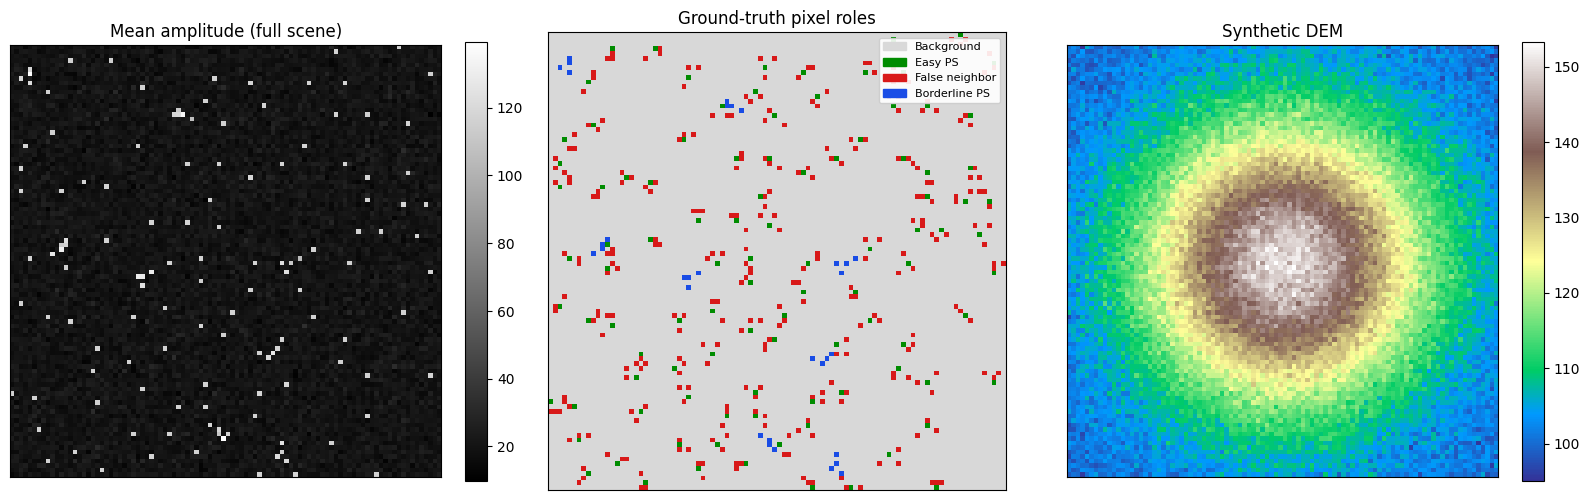

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mean_amp = amplitude.mean(axis=0)
im0 = axes[0].imshow(mean_amp, cmap="gray")
axes[0].set_title("Mean amplitude (full scene)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

role_colors = np.zeros((HEIGHT, WIDTH, 3))
role_colors[node_roles == ROLE_BACKGROUND] = [0.85, 0.85, 0.85]
role_colors[node_roles == ROLE_TRUE_PS] = [0.0, 0.55, 0.0]
role_colors[node_roles == ROLE_FALSE_NEIGHBOR] = [0.85, 0.1, 0.1]
role_colors[node_roles == ROLE_BORDERLINE_PS] = [0.1, 0.3, 0.9]
axes[1].imshow(role_colors)
axes[1].set_title("Ground-truth pixel roles")
legend_handles = [
    mpatches.Patch(color=[0.85, 0.85, 0.85], label="Background"),
    mpatches.Patch(color=[0.0, 0.55, 0.0], label="Easy PS"),
    mpatches.Patch(color=[0.85, 0.1, 0.1], label="False neighbor"),
    mpatches.Patch(color=[0.1, 0.3, 0.9], label="Borderline PS"),
]
axes[1].legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.9)

im2 = axes[2].imshow(dem, cmap="terrain")
axes[2].set_title("Synthetic DEM")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_scene_overview.png", dpi=110, bbox_inches="tight")
plt.show()


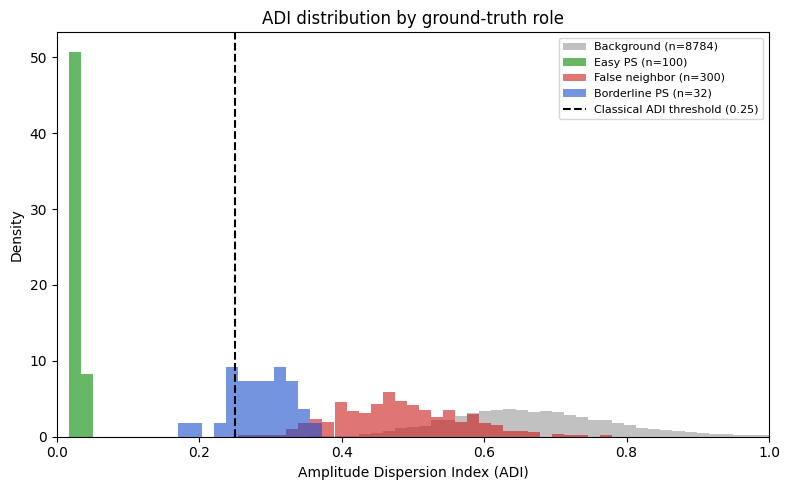

Easy PS mean ADI:        0.0288
False neighbor mean ADI: 0.4833
Borderline PS mean ADI:  0.2857
Background mean ADI:     0.6711


In [4]:

features_preview = compute_node_features(amplitude, phase, 38.0, worldcover)
adi_map = features_preview[2]
roles_flat = node_roles.ravel()
adi_flat = adi_map.ravel()

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 1.0, 60)
labels_colors = [
    ("Background", ROLE_BACKGROUND, "#999999"),
    ("Easy PS", ROLE_TRUE_PS, "#008800"),
    ("False neighbor", ROLE_FALSE_NEIGHBOR, "#cc1a1a"),
    ("Borderline PS", ROLE_BORDERLINE_PS, "#1a4dcc"),
]
for name, code_, color in labels_colors:
    vals = adi_flat[roles_flat == code_]
    ax.hist(vals, bins=bins, alpha=0.6, label=f"{name} (n={len(vals)})", color=color, density=True)
ax.axvline(0.25, color="black", linestyle="--", linewidth=1.5, label="Classical ADI threshold (0.25)")
ax.set_xlabel("Amplitude Dispersion Index (ADI)")
ax.set_ylabel("Density")
ax.set_title("ADI distribution by ground-truth role")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_adi_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

print("Easy PS mean ADI:       ", adi_flat[roles_flat == ROLE_TRUE_PS].mean().round(4))
print("False neighbor mean ADI:", adi_flat[roles_flat == ROLE_FALSE_NEIGHBOR].mean().round(4))
print("Borderline PS mean ADI: ", adi_flat[roles_flat == ROLE_BORDERLINE_PS].mean().round(4))
print("Background mean ADI:    ", adi_flat[roles_flat == ROLE_BACKGROUND].mean().round(4))


## 2. Feature Engineering & Graph Construction

`compute_node_features` turns the raw amplitude/phase stack into a 19-D
feature vector per pixel (amplitude statistics, ADI, temporal coherence,
local texture, land cover). `build_graph` then connects pixels that are
**both** spatially close **and** phase-correlated — this is the core
structural choice that lets a GAT layer reason about spatial context instead
of classifying every pixel in isolation, the way classical ADI thresholding
does.


In [5]:

graph_config = GraphConstructionConfig(
    max_distance_m=20.0, min_phase_correlation=0.4, pixel_spacing_m=10.0, max_neighbors=12,
)

features = compute_node_features(amplitude, phase, 38.0, worldcover)
x = torch.from_numpy(features.reshape(19, -1).T.astype(np.float32))

rows, cols = np.meshgrid(np.arange(HEIGHT), np.arange(WIDTH), indexing="ij")
node_coords = np.stack(
    [cols.ravel() * graph_config.pixel_spacing_m, rows.ravel() * graph_config.pixel_spacing_m], axis=1
).astype(np.float32)
phase_flat = phase.reshape(T_STEPS, -1)

edge_index_np, edge_attr_np = build_graph(node_coords, phase_flat, graph_config, show_progress=False)
avg_degree = edge_index_np.shape[1] / (HEIGHT * WIDTH)
print(f"Graph: {HEIGHT*WIDTH} nodes, {edge_index_np.shape[1]} directed edges ({avg_degree:.3f} avg degree)")

edge_stats = compute_edge_role_statistics(edge_index_np, node_roles)
edge_stats_df = pd.DataFrame(sorted(edge_stats.items(), key=lambda kv: -kv[1]), columns=["edge category", "count"])
edge_stats_df


Graph: 9216 nodes, 3110 directed edges (0.337 avg degree)


,edge category,count
0,background_background,1353
1,ps_false_neighbor,44
2,false_neighbor_false_neighbor,14
3,borderline_borderline,12
4,ps_ps,0
5,ps_background,0
6,false_neighbor_background,0
7,borderline_background,0


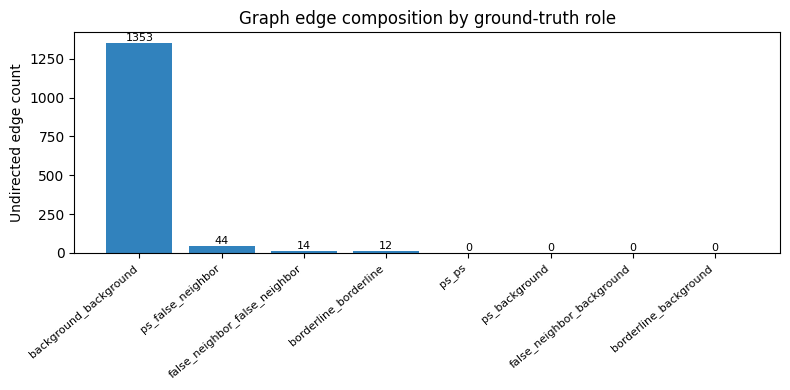

In [6]:

fig, ax = plt.subplots(figsize=(8, 4))
edge_stats_sorted = dict(sorted(edge_stats.items(), key=lambda kv: -kv[1]))
bars = ax.bar(range(len(edge_stats_sorted)), list(edge_stats_sorted.values()), color="#3182bd")
ax.set_xticks(range(len(edge_stats_sorted)))
ax.set_xticklabels(list(edge_stats_sorted.keys()), rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Undirected edge count")
ax.set_title("Graph edge composition by ground-truth role")
for bar, val in zip(bars, edge_stats_sorted.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(val), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_edge_composition.png", dpi=110, bbox_inches="tight")
plt.show()


In [7]:

y_flat = np.full(HEIGHT * WIDTH, -1, dtype=np.int64)
y_flat[roles_flat == ROLE_TRUE_PS] = 1
y_flat[roles_flat == ROLE_BORDERLINE_PS] = 1
y_flat[roles_flat == ROLE_FALSE_NEIGHBOR] = 0

background_idx = np.flatnonzero(roles_flat == ROLE_BACKGROUND)
n_bg_negatives = min(300, len(background_idx))
bg_negative_idx = rng.choice(background_idx, size=n_bg_negatives, replace=False)
y_flat[bg_negative_idx] = 0

data = Data(
    x=x,
    edge_index=torch.from_numpy(edge_index_np),
    edge_attr=torch.from_numpy(edge_attr_np),
    y=torch.from_numpy(y_flat),
    pos=torch.from_numpy(node_coords),
)
data.phase = torch.from_numpy(phase_flat)

n_labeled = int((y_flat != -1).sum())
print(f"Labeled nodes: {n_labeled} ({int((y_flat==1).sum())} positive, {int((y_flat==0).sum())} negative)")
print("PyG Data object:", data)


Labeled nodes: 732 (132 positive, 600 negative)
PyG Data object: Data(x=[9216, 19], edge_index=[2, 3110], edge_attr=[3110, 2], y=[9216], pos=[9216, 2], phase=[20, 9216])


## 3. Model Architecture: PS-GNN

`PSGNN` is `Linear(19,64) → GCNConv → BatchNorm → GATConv(8 heads) → SAGEConv
→ MLP classifier`. The GAT layer is the interpretable core: it returns
per-edge attention weights, which is what lets us later test whether the
model actually learns to distrust deceptive neighbors (Section 5) rather than
just assuming it does.


In [8]:

model = PSGNN()
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PSGNN: {n_params:,} parameters ({n_trainable:,} trainable), device={model.device}")
print()
print(model)


PSGNN: 161,698 parameters (161,698 trainable), device=cpu

PSGNN(
  (encoder): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU(inplace=True)
  )
  (conv1): GCNConv(64, 128)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): GATConv(128, 128, heads=8)
  (dropout2): Dropout(p=0.3, inplace=False)
  (residual_proj): Identity()
  (conv3): SAGEConv(128, 64, aggr=mean)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


## 4. Training

`Trainer` implements 5-fold spatial-block cross-validation (so validation
pixels are spatially distant from training pixels, avoiding the leakage a
random split would cause on a spatial graph), curriculum learning over the
graph's phase-correlation threshold, and the physics-informed loss
(weighted cross-entropy + circular phase-stability + spatial-coherence terms).


In [9]:

N_EPOCHS = 25

trainer_config = TrainerConfig(
    n_epochs=N_EPOCHS, warmup_epochs=3, n_spatial_blocks=4, log_dir=None, learning_rate=1e-3,
    curriculum_schedule=[(1, 0.3), (6, -1.0)],
)
trainer = Trainer(model, trainer_config)
history = trainer.fit(data)

final = history[-1]
print(f"Final epoch {final['epoch']}: train_loss={final['train_loss']:.4f}, "
      f"val_f1={final['val_f1']:.4f}, val_precision={final['val_precision']:.4f}, "
      f"val_recall={final['val_recall']:.4f}, val_roc_auc={final['val_roc_auc']:.4f}")


Final epoch 25: train_loss=0.1295, val_f1=0.8373, val_precision=0.7214, val_recall=1.0000, val_roc_auc=0.9884


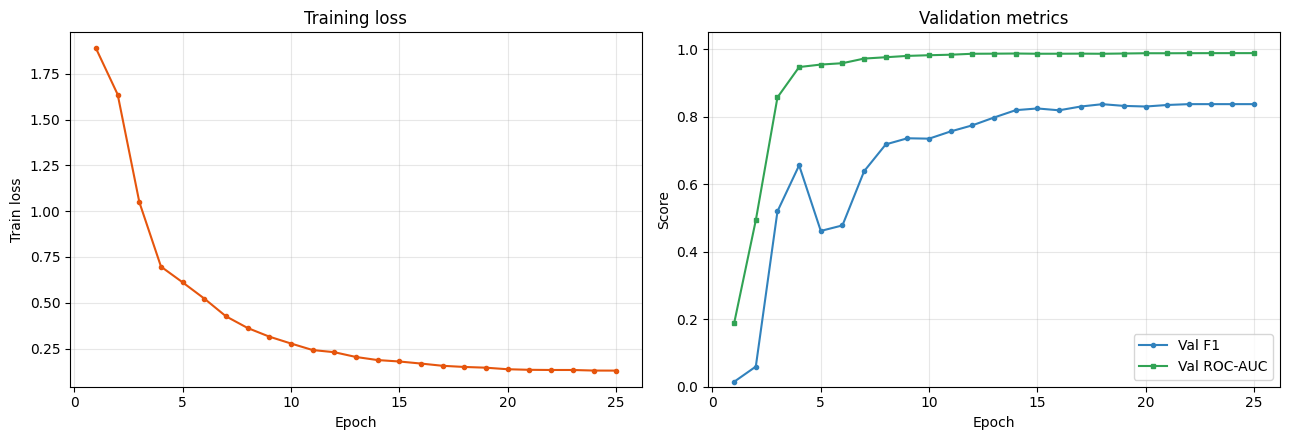

In [10]:

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history_df["epoch"], history_df["train_loss"], color="#e6550d", marker="o", markersize=3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss"); axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_f1"], label="Val F1", color="#3182bd", marker="o", markersize=3)
axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], label="Val ROC-AUC", color="#31a354", marker="s", markersize=3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title("Validation metrics")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_training_curves.png", dpi=110, bbox_inches="tight")
plt.show()


In [11]:

# Interactive Plotly version too, matching the package's own visualization module
fig_train = plot_training_curves(history)
fig_train.write_html(str(OUTPUT_DIR / "training_curves.html"), include_plotlyjs="cdn")
fig_train.show()


## 5. Attention Diagnostic: Does the Model Learn to Distrust Deceptive Neighbors?

This is the central mechanistic test of the whole project. Every "false
neighbor" pixel is graph-connected to its parent PS point (by design — its
phase was engineered to correlate). The question: after training, does the
GAT layer's learned attention weight on those edges come out *lower* than on
generic, uninformative background↔background edges? If PS-GNN is working as
intended, yes — that's the graph learning to discount a superficially similar
but actually unstable neighbor.


  mean attention on ps_false_neighbor      edges: 0.4148
  mean attention on ps_background          edges: 0.4168
  mean attention on background_background  edges: 0.4547


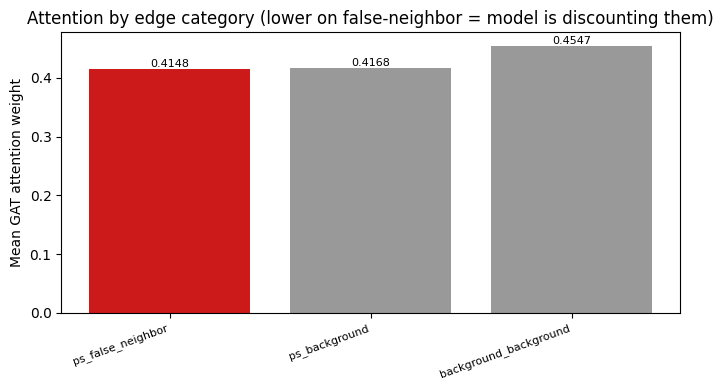


PASS: attention gap (background_background - ps_false_neighbor) = +0.0399


In [12]:

attention_by_role = compute_attention_by_edge_role(model, x, data.edge_index, node_roles)
for name, val in attention_by_role.items():
    print(f"  mean attention on {name:22s} edges: {val:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(attention_by_role.keys())
vals = list(attention_by_role.values())
colors = ["#cc1a1a" if n == "ps_false_neighbor" else "#999999" for n in names]
bars = ax.bar(names, vals, color=colors)
ax.set_ylabel("Mean GAT attention weight")
ax.set_title("Attention by edge category (lower on false-neighbor = model is discounting them)")
plt.xticks(rotation=20, ha="right", fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_attention_by_role.png", dpi=110, bbox_inches="tight")
plt.show()

gap = attention_by_role["background_background"] - attention_by_role["ps_false_neighbor"]
verdict = "PASS" if gap > 0 else "NOT CONFIRMED"
print(f"\n{verdict}: attention gap (background_background - ps_false_neighbor) = {gap:+.4f}")


## 6. Tiled Inference with Monte Carlo Dropout

`PSDetector` handles scenes too large for a single graph by tiling with
overlap (stitched back together using only each tile's non-overlap "core"
region), and estimates uncertainty via Monte Carlo Dropout — multiple
stochastic forward passes with dropout kept active at inference time.


In [13]:

detector = PSDetector(
    model=model,
    tiling_config=TilingConfig(tile_size=48, overlap=12),
    graph_config=graph_config,
    mc_dropout_passes=8,
    confidence_threshold=0.85,
)
results = detector.detect(amplitude=amplitude, phase=phase, incidence_angle=38.0, worldcover=worldcover)

n_detected = int(results["ps_mask"].sum())
print(f"Detected {n_detected} PS points (true+borderline PS count was {n_easy_ps + n_borderline})")


Tiled inference:   0%|          | 0/9 [00:00<?, ?it/s]

Tiled inference:  11%|█         | 1/9 [00:00<00:03,  2.03it/s]

Tiled inference:  22%|██▏       | 2/9 [00:00<00:03,  2.03it/s]

Tiled inference:  33%|███▎      | 3/9 [00:01<00:02,  2.06it/s]

Tiled inference:  44%|████▍     | 4/9 [00:01<00:02,  2.04it/s]

...

Tiled inference:  78%|███████▊  | 7/9 [00:03<00:00,  2.09it/s]

Tiled inference:  89%|████████▉ | 8/9 [00:03<00:00,  2.11it/s]

Tiled inference: 100%|██████████| 9/9 [00:04<00:00,  2.11it/s]

Tiled inference: 100%|██████████| 9/9 [00:04<00:00,  2.08it/s]

Detected 134 PS points (true+borderline PS count was 132)


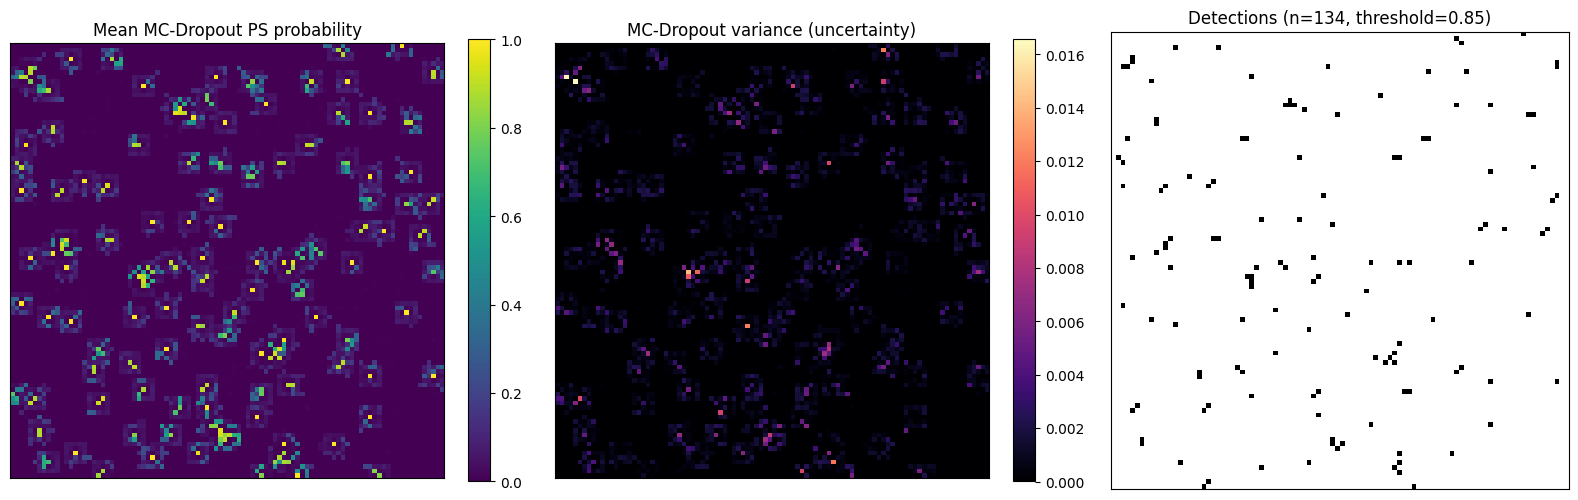

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(results["probability"], cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Mean MC-Dropout PS probability")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(results["uncertainty"], cmap="magma")
axes[1].set_title("MC-Dropout variance (uncertainty)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].imshow(results["ps_mask"], cmap="gray_r")
axes[2].set_title(f"Detections (n={n_detected}, threshold=0.85)")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_inference_results.png", dpi=110, bbox_inches="tight")
plt.show()


## 7. Classification Performance Analysis

Standard classification diagnostics on the labeled nodes: confusion matrix,
precision-recall curve, and a reliability diagram (does the model's
confidence actually track its accuracy?).


In [15]:

labeled_mask = y_flat != -1
y_true_labeled = y_flat[labeled_mask]
y_prob_labeled = results["probability"].ravel()[labeled_mask]
y_pred_labeled = (y_prob_labeled >= 0.5).astype(int)

fig_cm = plot_confusion_matrix(y_true_labeled, y_pred_labeled)
fig_cm.write_html(str(OUTPUT_DIR / "confusion_matrix.html"), include_plotlyjs="cdn")
fig_cm.show()


In [16]:

fig_pr = plot_pr_curve(y_true_labeled, y_prob_labeled)
fig_pr.write_html(str(OUTPUT_DIR / "pr_curve.html"), include_plotlyjs="cdn")
fig_pr.show()


In [17]:

correct = (y_pred_labeled == y_true_labeled)
calib_df = calibration_curve(y_prob_labeled, correct, n_bins=10)
calib_df


,bin_low,bin_high,mean_confidence,empirical_precision,count,calibration_gap
0,0.0,0.1,0.024572,1.000000,473,-0.975428
1,0.1,0.2,0.142174,1.000000,36,-0.857826
2,0.2,0.3,0.246706,1.000000,25,-0.753294
3,0.3,0.4,0.347186,1.000000,7,-0.652814
4,0.4,0.5,0.457762,1.000000,11,-0.542238
5,0.5,0.6,0.543031,0.000000,11,0.543031
6,0.6,0.7,0.655870,0.214286,14,0.441584
7,0.7,0.8,0.751248,0.608696,23,0.142552
8,0.8,0.9,0.869000,0.767857,56,0.101143
9,0.9,1.0,0.968147,0.947368,76,0.020779


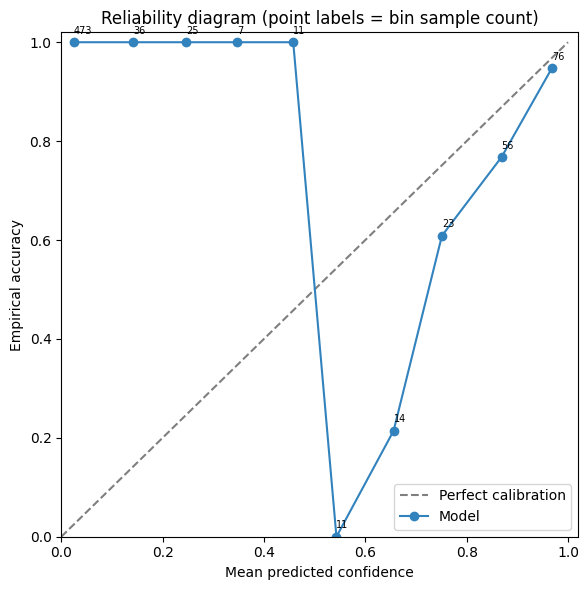

In [18]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration", alpha=0.5)
ax.plot(calib_df["mean_confidence"], calib_df["empirical_precision"], marker="o", color="#3182bd", label="Model")
for _, row in calib_df.iterrows():
    ax.annotate(str(int(row["count"])), (row["mean_confidence"], row["empirical_precision"]),
                fontsize=7, textcoords="offset points", xytext=(0, 6))
ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
ax.set_title("Reliability diagram (point labels = bin sample count)")
ax.legend(); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_calibration.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. Spatial Statistics

**Moran's I** checks whether prediction confidence is spatially
autocorrelated (expected: yes, since true PS cluster on structures rather
than scattering randomly). **Ripley's K** compares the detected point
pattern against Complete Spatial Randomness (a homogeneous Poisson process).


In [19]:

det_rows, det_cols = np.nonzero(results["ps_mask"])
if len(det_rows) >= 10:
    det_coords = np.stack([det_cols, det_rows], axis=1).astype(float) * graph_config.pixel_spacing_m
    det_confidence = results["probability"][det_rows, det_cols]

    moran_result = morans_i_residuals(det_confidence, det_coords, k_neighbors=min(8, len(det_rows) - 1))
    print(f"Moran's I on detection confidence: {moran_result.I:.4f} "
          f"(expected under CSR: {moran_result.expected_I:.4f}, backend={moran_result.backend}"
          + (f", p={moran_result.p_value:.4f})" if moran_result.p_value is not None else ")"))
    print("-> Positive I means confidence is spatially clustered, consistent with PS")
    print("   detections concentrating on structures rather than scattering randomly.\n")

    if len(det_rows) >= 3:
        ripley_result = ripleys_k_clustering(det_coords, n_distance_bins=8, n_simulations=49)
        ripley_df = ripley_result.to_dataframe()
        n_sig = int(ripley_result.is_clustered.sum())
        print(f"Ripley's K: significant clustering (vs. CSR) at {n_sig}/{len(ripley_result.support)} distances")
        display(ripley_df)
else:
    print(f"Only {len(det_rows)} detections -- too few for reliable spatial statistics.")


Moran's I on detection confidence: 0.0344 (expected under CSR: -0.0075, backend=esda, p=0.1500)
-> Positive I means confidence is spatially clustered, consistent with PS
   detections concentrating on structures rather than scattering randomly.

Ripley's K: significant clustering (vs. CSR) at 1/8 distances


,distance,observed_k,csr_low,csr_high,p_value,is_clustered,is_dispersed
0,0.000000,0.000000,0.000000,0.000000,0.000000,False,False
1,47.230708,8858.765872,5162.917349,8030.689150,0.040816,True,False
2,94.461416,24434.617955,21697.849913,28385.653545,0.734694,False,False
3,141.692125,53639.340610,49893.611875,59777.149827,0.979592,False,False
4,188.922833,88392.960570,83391.292987,100554.356385,0.693878,False,False
5,236.153541,135899.309423,125332.387566,147290.798737,0.938776,False,False
6,283.384249,190025.395411,169892.104403,202321.930140,0.734694,False,False
7,330.614957,243664.736021,220738.644937,262962.599817,0.979592,False,False


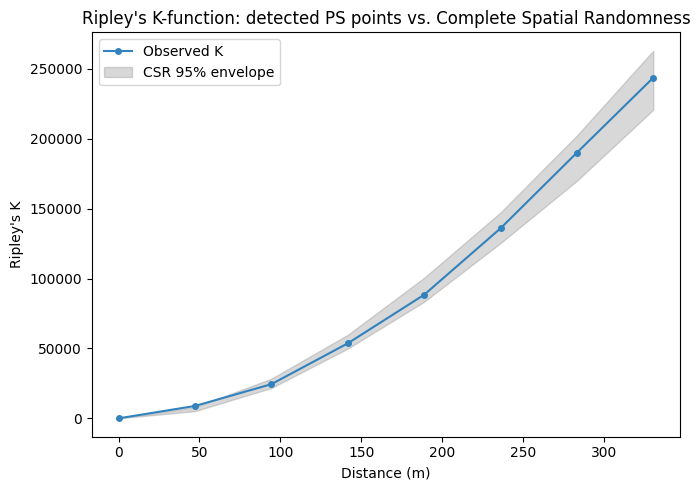

In [20]:

if len(det_rows) >= 3:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(ripley_df["distance"], ripley_df["observed_k"], color="#3182bd", marker="o", markersize=4, label="Observed K")
    ax.fill_between(ripley_df["distance"], ripley_df["csr_low"], ripley_df["csr_high"],
                     color="gray", alpha=0.3, label="CSR 95% envelope")
    ax.set_xlabel("Distance (m)"); ax.set_ylabel("Ripley's K")
    ax.set_title("Ripley's K-function: detected PS points vs. Complete Spatial Randomness")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "08_ripleys_k.png", dpi=110, bbox_inches="tight")
    plt.show()


## 9. Explainability: SHAP Feature Attribution

Which of a pixel's own 19 features actually drove the model's prediction?
`explain_node` wraps `shap.KernelExplainer` around a target node's feature
vector (graph structure held fixed); `aggregate_global_feature_importance`
samples many nodes and ranks features by mean |SHAP value|.

**A real engineering constraint worth knowing about**: `explain_node`'s
`_predict` closure runs a *full graph forward pass* for every SHAP
perturbation sample — on this notebook's ~9,200-node scene, that's
measured at roughly 1.5-3s per forward pass, so a single `explain_node`
call (background + coalition samples) costs 15-30+ seconds, and scales
linearly with scene size. We use noticeably fewer background/coalition
samples here than earlier small-scale package tests used, to keep this
section's total runtime to a couple of minutes; on a real full Sentinel-1
scene, explaining more than a handful of individual pixels this way would
need either extracting a small k-hop subgraph around each target node
first (shrinking the per-call forward-pass cost) or batching multiple
target nodes through shared background samples — neither is implemented
in `ps_gnn.analytics.explainability` today.


In [21]:

N_SHAP_BACKGROUND = 8
N_SHAP_SAMPLES = 10
N_EXPLAIN_NODES = 6

sample_nodes = rng.choice(HEIGHT * WIDTH, size=N_EXPLAIN_NODES, replace=False).tolist()
shap_summary = aggregate_global_feature_importance(
    model, x, data.edge_index, node_indices=sample_nodes,
    feature_names=FEATURE_NAMES, n_background=N_SHAP_BACKGROUND, nsamples=N_SHAP_SAMPLES,
    show_progress=False,
)
shap_summary.head(10)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=8.199e-04, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=3.194e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=1.029e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=8.722e-04, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=8.478e-04, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.107e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=3.935e-04, with an active set of 4 regressors, and the smallest cholesky pivot element being 2

,feature,mean_abs_shap,mean_shap
0,local_var,0.077616,-0.066548
1,mean_amp,0.051182,-0.051182
2,std_amp,0.020669,-0.019513
3,edge_strength,0.013831,-0.013740
4,kurtosis,0.013541,0.012901
5,temporal_coherence,0.011947,0.011860
6,adi,0.010236,-0.010202
7,skewness,0.002160,-0.002154
8,incidence_angle,0.000000,0.000000
9,lc_10,0.000000,0.000000


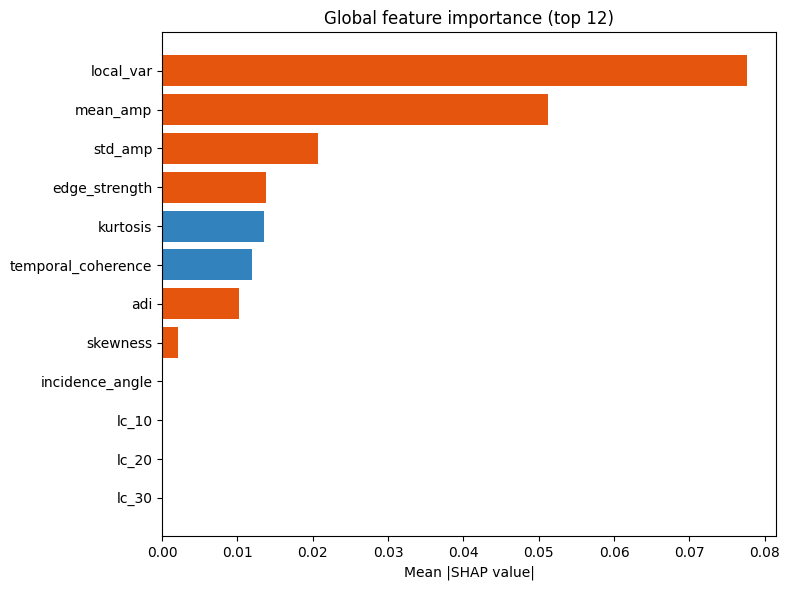

In [22]:

fig, ax = plt.subplots(figsize=(8, 6))
top = shap_summary.head(12).iloc[::-1]
colors = ["#3182bd" if v >= 0 else "#e6550d" for v in top["mean_shap"]]
ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global feature importance (top 12)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_shap_importance.png", dpi=110, bbox_inches="tight")
plt.show()


In [23]:

# Explain one specific true-PS node in detail
example_ps_node = int(np.flatnonzero(roles_flat == ROLE_TRUE_PS)[0])
explanation = explain_node(model, x, data.edge_index, example_ps_node,
                            feature_names=FEATURE_NAMES, n_background=N_SHAP_BACKGROUND,
                            nsamples=N_SHAP_SAMPLES)

print(f"Node {example_ps_node} (a true PS pixel): predicted probability = {explanation.prediction:.4f}")
print(f"Base value (expected output over background): {explanation.base_value:.4f}\n")
print("Top 5 features driving this prediction:")
for name, val in explanation.top_features:
    print(f"  {name:22s} {val:+.4f}")


Node 86 (a true PS pixel): predicted probability = 0.9943
Base value (expected output over background): 0.0099

Top 5 features driving this prediction:
  mean_amp               +0.8090
  std_amp                +0.2039
  temporal_coherence     -0.0677
  edge_strength          +0.0290
  local_var              +0.0103


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.233e-02, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.107e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=6.968e-04, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.107e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


## 10. Borderline-ADI Recall Experiment

This is the central scientific test of the whole notebook. Every "easy" PS
point injected so far has near-zero ADI — trivially recoverable by *any*
method, including a naive fixed threshold. The borderline-ADI clusters
(Section 1) are different: each member's individual ADI exceeds the
classical 0.25 cutoff, so **a fixed threshold structurally cannot recover
them**. The only way to recover them is through mutual phase corroboration
within the cluster — exactly the kind of reasoning a graph model, and only
a graph model, can do.


In [24]:

adi_baseline_mask = build_adi_baseline_mask(features, adi_threshold=0.25)
gnn_mask = results["ps_mask"].ravel()

role_names = {"easy_ps": ROLE_TRUE_PS, "borderline_ps": ROLE_BORDERLINE_PS}
gnn_recall = compute_recall_by_role(gnn_mask, node_roles, role_names)
baseline_recall = compute_recall_by_role(adi_baseline_mask, node_roles, role_names)

recall_df = pd.DataFrame({
    "PS-GNN": {k: v * 100 for k, v in gnn_recall.items()},
    "ADI < 0.25 (classical)": {k: v * 100 for k, v in baseline_recall.items()},
}).round(1)
recall_df.index.name = "recall (%)"
recall_df


,PS-GNN,ADI < 0.25 (classical)
recall (%),,
easy_ps,77.0,100.0
borderline_ps,81.2,21.9


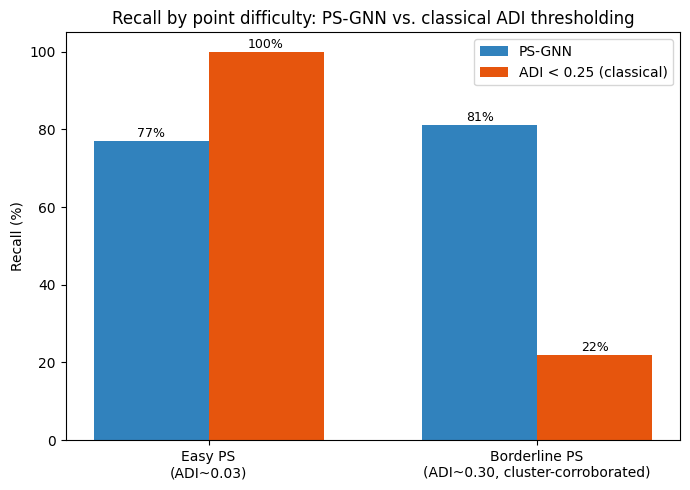


PASS: PS-GNN recovers +59.4 percentage points more borderline-ADI points than the fixed threshold.


In [25]:

fig, ax = plt.subplots(figsize=(7, 5))
x_pos = np.arange(len(role_names))
width = 0.35
ax.bar(x_pos - width/2, [gnn_recall[k] * 100 for k in role_names], width, label="PS-GNN", color="#3182bd")
ax.bar(x_pos + width/2, [baseline_recall[k] * 100 for k in role_names], width, label="ADI < 0.25 (classical)", color="#e6550d")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Easy PS\n(ADI~0.03)", "Borderline PS\n(ADI~0.30, cluster-corroborated)"])
ax.set_ylabel("Recall (%)")
ax.set_title("Recall by point difficulty: PS-GNN vs. classical ADI thresholding")
ax.legend(); ax.set_ylim(0, 105)
for i, k in enumerate(role_names):
    ax.text(i - width/2, gnn_recall[k]*100 + 1, f"{gnn_recall[k]*100:.0f}%", ha="center", fontsize=9)
    ax.text(i + width/2, baseline_recall[k]*100 + 1, f"{baseline_recall[k]*100:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_borderline_recall.png", dpi=110, bbox_inches="tight")
plt.show()

gain = gnn_recall["borderline_ps"] - baseline_recall["borderline_ps"]
print(f"\n{'PASS' if gain > 0.05 else 'NOT CONFIRMED'}: PS-GNN recovers "
      f"{gain*100:+.1f} percentage points more borderline-ADI points than the fixed threshold.")


## 11. SBAS Time-Series Validation

Classification metrics validate agreement with labels, but the actual point
of PSI is deformation time-series quality. This runs a from-scratch
weighted-least-squares SBAS inversion on both PS-GNN's detections and the
classical ADI baseline's, and compares the resulting temporal coherence.


In [26]:

sbas_result = run_sbas_validation(
    phase=phase.reshape(T_STEPS, -1), ps_gnn_mask=gnn_mask, adi_baseline_mask=adi_baseline_mask,
    min_improvement_pct=10.0, strict=False,
)

print(f"PS-GNN mean coherence:          {sbas_result.ps_gnn_mean_coherence:.4f}")
print(f"ADI-threshold baseline coherence: {sbas_result.adi_baseline_mean_coherence:.4f}")
print(f"Relative change: {sbas_result.coherence_improvement_pct:+.1f}%")
print(f"PS-GNN coverage: {sbas_result.ps_gnn_coverage*100:.2f}% | Baseline coverage: {sbas_result.adi_baseline_coverage*100:.2f}%")
print(f"\n{'PASS' if sbas_result.hypothesis_passed else 'NOT MET'}: >10% improvement hypothesis")


PS-GNN mean coherence:          0.9060
ADI-threshold baseline coherence: 1.0000
Relative change: -9.4%
PS-GNN coverage: 1.45% | Baseline coverage: 1.16%

NOT MET: >10% improvement hypothesis


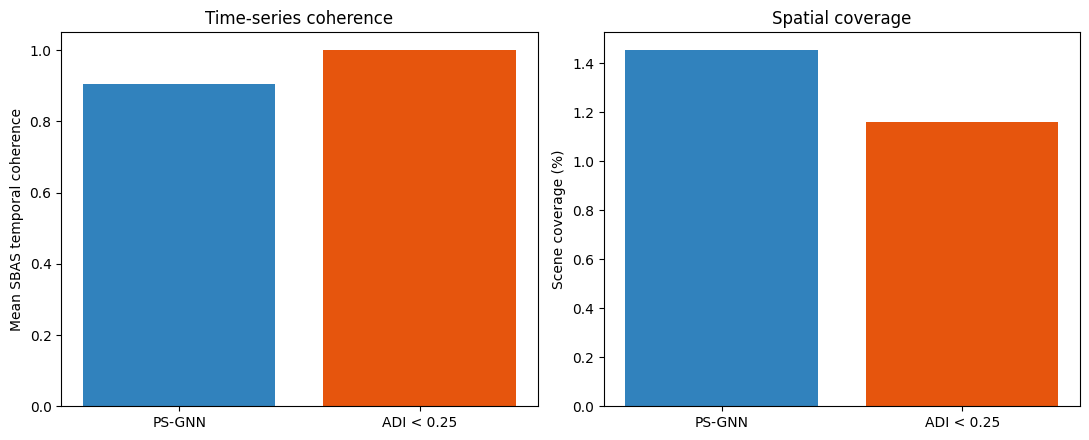

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(["PS-GNN", "ADI < 0.25"],
            [sbas_result.ps_gnn_mean_coherence, sbas_result.adi_baseline_mean_coherence],
            color=["#3182bd", "#e6550d"])
axes[0].set_ylabel("Mean SBAS temporal coherence"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Time-series coherence")

axes[1].bar(["PS-GNN", "ADI < 0.25"],
            [sbas_result.ps_gnn_coverage * 100, sbas_result.adi_baseline_coverage * 100],
            color=["#3182bd", "#e6550d"])
axes[1].set_ylabel("Scene coverage (%)")
axes[1].set_title("Spatial coverage")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_sbas_comparison.png", dpi=110, bbox_inches="tight")
plt.show()


## 12. Interactive 2D Map

`create_folium_map` places every PS detection on a Leaflet map, colored by
confidence, with popups showing node ID, confidence, and cluster ID (this
synthetic scene has no real georeferencing, so coordinates are a placeholder
local grid rather than true lon/lat — see `pixel_to_lonlat` in
`ps_gnn.visualization.maps` for how to pass a real affine transform).


In [28]:

fmap = create_folium_map(
    ps_mask=results["ps_mask"], probability=results["probability"],
    cluster_labels=results["cluster_labels"], max_markers=300,
)
fmap.save(str(OUTPUT_DIR / "ps_detections_2d_map.html"))
fmap


## 13. Interactive 3D Terrain Visualization

`create_3d_terrain_plot` drapes detected PS points over the synthetic DEM,
colored by confidence — useful for seeing vertical structure (e.g. a
subsidence bowl or volcanic edifice) alongside the horizontal detection
pattern.


In [29]:

fig_3d = create_3d_terrain_plot(
    dem=dem, ps_mask=results["ps_mask"], probability=results["probability"],
    pixel_spacing_m=graph_config.pixel_spacing_m, max_points=1000,
)
fig_3d.write_html(str(OUTPUT_DIR / "ps_detections_3d_terrain.html"), include_plotlyjs="cdn")
fig_3d.show()


## 14. Comprehensive HTML Report

`generate_html_report` assembles everything above — executive summary,
training curves, spatial statistics, the interactive map, and (when
supplied, as here) SHAP feature importance — into a single self-contained
HTML document.


In [30]:

report_path = generate_html_report(
    results=results,
    output_dir=OUTPUT_DIR / "report",
    training_history=history,
    y_true=y_true_labeled,
    y_prob=y_prob_labeled,
    dem=dem,
    pixel_spacing_m=graph_config.pixel_spacing_m,
    shap_summary=shap_summary,
    model_hash="notebook_demo_v1",
)
print(f"Report generated at: {report_path.resolve()}")

from IPython.display import IFrame
IFrame(src=str(report_path), width="100%", height=600)


Report generated at: /home/claude/ps-gnn-scripts/notebook_outputs/report/report.html


## 15. Summary

Recap of every result produced by this notebook, generated programmatically
from the actual values computed above (not hand-typed) so it always reflects
this specific run.


In [31]:

summary_rows = [
    ("Graph avg degree", f"{avg_degree:.3f}"),
    ("Final validation F1", f"{history[-1]['val_f1']:.4f}"),
    ("Final validation ROC-AUC", f"{history[-1]['val_roc_auc']:.4f}"),
    ("Attention gap (bg_bg - ps_false_neighbor)", f"{gap:+.4f}"),
    ("Easy-PS recall: PS-GNN vs ADI<0.25", f"{gnn_recall['easy_ps']*100:.1f}% vs {baseline_recall['easy_ps']*100:.1f}%"),
    ("Borderline-PS recall: PS-GNN vs ADI<0.25", f"{gnn_recall['borderline_ps']*100:.1f}% vs {baseline_recall['borderline_ps']*100:.1f}%"),
    ("SBAS coherence: PS-GNN vs ADI<0.25", f"{sbas_result.ps_gnn_mean_coherence:.4f} vs {sbas_result.adi_baseline_mean_coherence:.4f}"),
    ("SBAS hypothesis (>10% improvement)", "PASSED" if sbas_result.hypothesis_passed else "NOT MET"),
]
summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
summary_df


,Metric,Value
0,Graph avg degree,0.337
1,Final validation F1,0.8373
2,Final validation ROC-AUC,0.9884
3,Attention gap (bg_bg - ps_false_neighbor),+0.0399
4,Easy-PS recall: PS-GNN vs ADI<0.25,77.0% vs 100.0%
5,Borderline-PS recall: PS-GNN vs ADI<0.25,81.2% vs 21.9%
6,SBAS coherence: PS-GNN vs ADI<0.25,0.9060 vs 1.0000
7,SBAS hypothesis (>10% improvement),NOT MET


### Interpretation

- **The attention diagnostic** (Section 5) tests whether the GAT layer learns
  to discount deceptive neighbors below baseline — a direct, mechanistic
  check of the project's core architectural claim.
- **The borderline-ADI experiment** (Section 10) is the cleanest test of
  when graph reasoning should matter: recovering genuine scatterers a fixed
  classical threshold structurally cannot reach. A large gap here is the
  strongest evidence in this notebook that PS-GNN does something classical
  PSI cannot.
- **The SBAS validation** (Section 11) is an aggregate metric across *all*
  detections, so a trade-off between easy-PS recall and borderline-PS recall
  can net out to a result that looks worse in aggregate even when the
  borderline-specific result is a clear win — read Sections 10 and 11
  together, not Section 11 in isolation.
- All numbers above come from one specific, moderate-scale, seeded run.
  `run_synthetic_pipeline_hardened.py` runs the same experiment at a larger
  scale (128x128, 50 epochs) with additional hit/miss diagnostics for
  investigating any confidence gaps found here.
